##ML lab 4

## 1. Load dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

df = pd.read_csv("BC Dataset.csv")

print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

## 2. Data Quality Assessment
### 2.1 Check Data Types

In [3]:
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


## 3. Handling Missing Values

In [6]:
df.isna()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [7]:
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [8]:
df_cleaned = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# I dropped 'Unnamed: 32' because it contains no data, We drop 'id' because it is a unique identifier
# that does not contribute to machine learning patterns.

In [9]:
df_cleaned.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


## 4. Handling Outliers

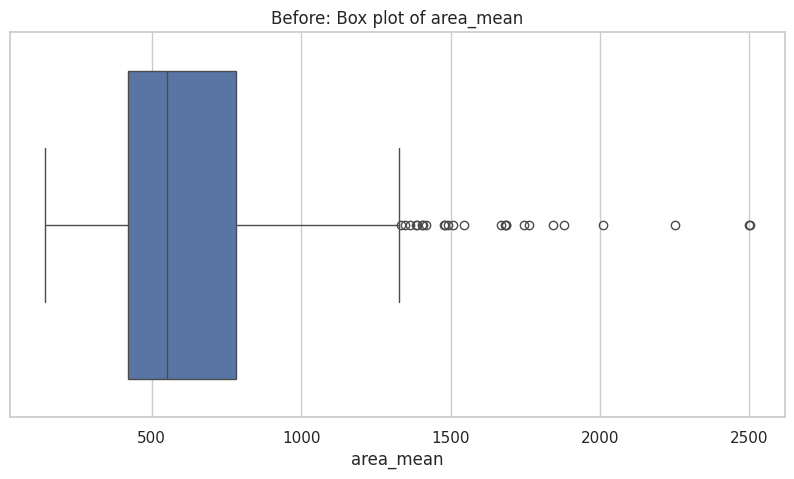

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned['area_mean'])
plt.title('Before: Box plot of area_mean')
plt.show()

In [18]:
# 2. Detect outliers using IQR
Q1 = df_cleaned['area_mean'].quantile(0.25)
Q3 = df_cleaned['area_mean'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['area_mean'] < lower_bound) | (df_cleaned['area_mean'] > upper_bound)]
outliers.head(15)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
23,M,21.16,23.04,137.2,1404.0,0.09428,0.10220,0.1097,0.08632,0.1769,...,29.17,35.59,188.0,2615.0,0.1401,0.2600,0.3155,0.2009,0.2822,0.07526
82,M,25.22,24.91,171.5,1878.0,0.10630,0.26650,0.3339,0.18450,0.1829,...,30.00,33.62,211.7,2562.0,0.1573,0.6076,0.6476,0.2867,0.2355,0.10510
108,M,22.27,19.67,152.8,1509.0,0.13260,0.27680,0.4264,0.18230,0.2556,...,28.40,28.01,206.8,2360.0,0.1701,0.6997,0.9608,0.2910,0.4055,0.09789
122,M,24.25,20.20,166.2,1761.0,0.14470,0.28670,0.4268,0.20120,0.2655,...,26.02,23.99,180.9,2073.0,0.1696,0.4244,0.5803,0.2248,0.3222,0.08009
164,M,23.27,22.04,152.1,1686.0,0.08439,0.11450,0.1324,0.09702,0.1801,...,28.01,28.22,184.2,2403.0,0.1228,0.3583,0.3948,0.2346,0.3589,0.09187
180,M,27.22,21.87,182.1,2250.0,0.10940,0.19140,0.2871,0.18780,0.1800,...,33.12,32.85,220.8,3216.0,0.1472,0.4034,0.5340,0.2688,0.2856,0.08082
202,M,23.29,26.67,158.9,1685.0,0.11410,0.20840,0.3523,0.16200,0.2200,...,25.12,32.68,177.0,1986.0,0.1536,0.4167,0.7892,0.2733,0.3198,0.08762
212,M,28.11,18.47,188.5,2499.0,0.11420,0.15160,0.3201,0.15950,0.1648,...,28.11,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525
236,M,23.21,26.97,153.5,1670.0,0.09509,0.16820,0.1950,0.12370,0.1909,...,31.01,34.51,206.0,2944.0,0.1481,0.4126,0.5820,0.2593,0.3103,0.08677
250,M,20.94,23.56,138.9,1364.0,0.10070,0.16060,0.2712,0.13100,0.2205,...,25.58,27.00,165.3,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849


In [19]:
df_no_outliers = df_cleaned[(df_cleaned['area_mean'] >= lower_bound) & (df_cleaned['area_mean'] <= upper_bound)]
print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (569, 33)
df without outliers:  (544, 31)


### Capping Outliers (Percentile Method)

In [20]:
lower_cap = df['area_mean'].quantile(0.05) # 5%
upper_cap = df['area_mean'].quantile(0.95) # 95%

df_capped = df.copy()
df_capped['area_mean'] = df_capped['area_mean'].clip(lower_cap, upper_cap)

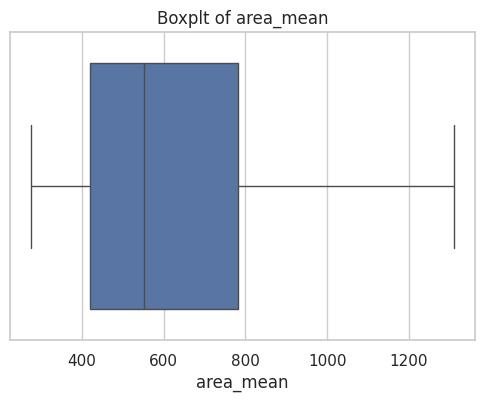

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['area_mean'])

plt.title('Boxplt of area_mean')
plt.show()

##5.Normalization

In [25]:
# 1. Min-Max Normalization
df_no_outliers['radius_mean_minmax'] = (df_no_outliers['radius_mean'] - df_no_outliers['radius_mean'].min()) / (df_no_outliers['radius_mean'].max() - df_no_outliers['radius_mean'].min())

# 2. Z-score Normalization (Standardization)
df_no_outliers['radius_mean_zscore'] = (df_no_outliers['radius_mean'] - df_no_outliers['radius_mean'].mean()) / df_no_outliers['radius_mean'].std()

print(df_no_outliers[['radius_mean', 'radius_mean_minmax', 'radius_mean_zscore']].head())

   radius_mean  radius_mean_minmax  radius_mean_zscore
0        17.99            0.780282            1.430668
1        20.57            0.963144            2.294368
2        19.69            0.900773            1.999773
3        11.42            0.314622           -0.768751
4        20.29            0.943299            2.200633


/tmp/ipykernel_15680/187327280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['radius_mean_minmax'] = (df_no_outliers['radius_mean'] - df_no_outliers['radius_mean'].min()) / (df_no_outliers['radius_mean'].max() - df_no_outliers['radius_mean'].min())
/tmp/ipykernel_15680/187327280.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['radius_mean_zscore'] = (df_no_outliers['radius_mean'] - df_no_outliers['radius_mean'].mean()) / df_no_outliers['radius_mean'].std()


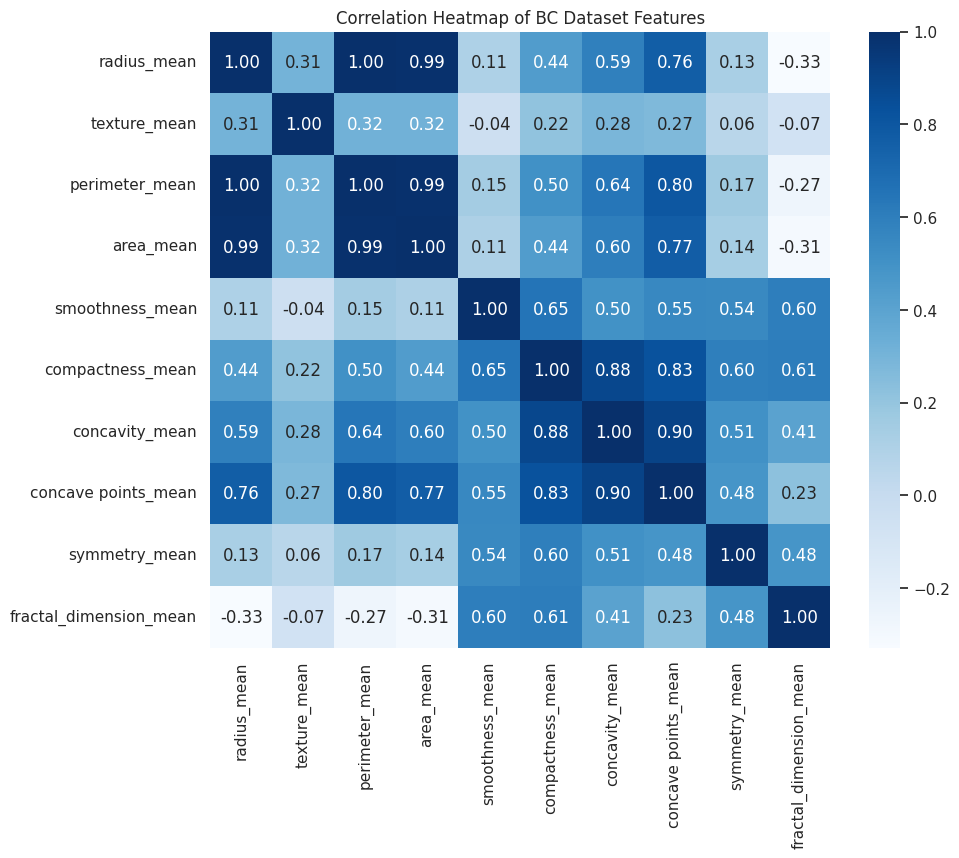

In [26]:
#check for correlation
corr_matrix = df_no_outliers.iloc[:, 1:11].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap of BC Dataset Features")
plt.show()

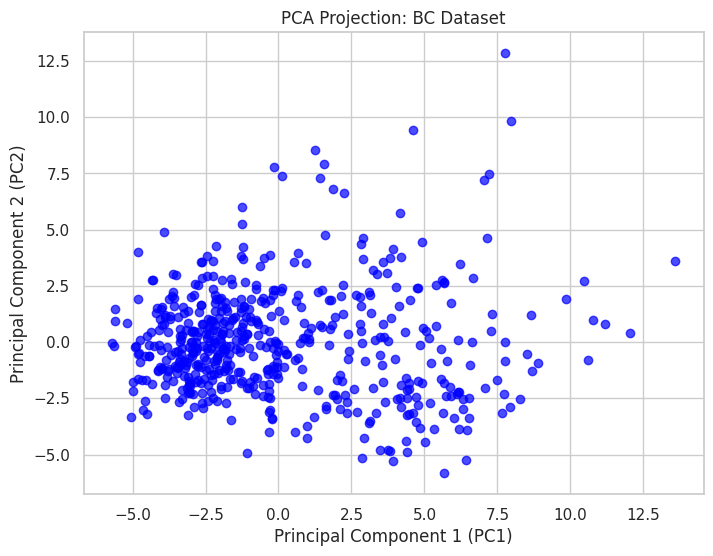

Explained Variance Ratio: [0.4371592  0.19252045]


In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_no_outliers.select_dtypes(include=[np.number]).drop(columns=['radius_mean_minmax', 'radius_mean_zscore'])
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
PC = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=PC, columns=['PC1', 'PC2'])

plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.7, c='blue')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA Projection: BC Dataset')
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)